# Udemy Course Price Prediction
##   Pre-launch pricing model

---
### Importing Libraries

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import Ridge

---
### Loading & Inpecting Dataset

In [136]:
df = pd.read_csv('udemy_courses_cleaned.csv')
df.head()

,published,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,published.1,year,quarter,month,profit,content_duration_cat,price_cat
0,2017-01-18,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,Business Finance,2017-01-18,2017,1,January,429400,1 : 3,170:200
1,2016-12-19,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,Business Finance,2016-12-19,2016,4,December,97830,1 : 3,20:50
2,2017-05-30,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,True,95,2451,11,36,All Levels,3.0,Business Finance,2017-05-30,2017,2,May,232845,1 : 3,80:110
3,2016-12-13,1011058,How To Maximize Your Profits Trading Options,https://www.udemy.com/how-to-maximize-your-pro...,True,200,1276,45,26,Intermediate Level,2.0,Business Finance,2016-12-13,2016,4,December,255200,1 : 3,170:200
4,2015-05-28,476268,Options Trading 3 : Advanced Stock Profit and ...,https://www.udemy.com/day-trading-stock-option...,True,195,5172,34,38,Expert Level,2.5,Business Finance,2015-05-28,2015,2,May,1008540,1 : 3,170:200


In [137]:
df.drop(columns={'is_paid' ,'profit' , 'num_subscribers' , 'num_reviews'} , inplace= True)

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2782 entries, 0 to 2781
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   published             2782 non-null   object 
 1   course_id             2782 non-null   int64  
 2   course_title          2782 non-null   object 
 3   url                   2782 non-null   object 
 4   price                 2782 non-null   int64  
 5   num_lectures          2782 non-null   int64  
 6   level                 2782 non-null   object 
 7   content_duration      2782 non-null   float64
 8   subject               2782 non-null   object 
 9   published.1           2782 non-null   object 
 10  year                  2782 non-null   int64  
 11  quarter               2782 non-null   int64  
 12  month                 2782 non-null   object 
 13  content_duration_cat  2782 non-null   object 
 14  price_cat             2782 non-null   object 
dtypes: float64(1), int64(

## Feature Engineering & Preprocessing

In [139]:
df['content_duration'] = round(df['content_duration'],2)

In [140]:
df['lectures_per_hour'] = df['num_lectures'] / (df['content_duration'] + 0.1)

In [141]:
df['is_long_course'] = (df['content_duration'] > 10).astype(int)

In [142]:
df.sample()

,published,course_id,course_title,url,price,num_lectures,level,content_duration,subject,published.1,year,quarter,month,content_duration_cat,price_cat,lectures_per_hour,is_long_course
2207,2017-05-09,1198654,How to set up a Web Server From Scratch to One...,https://www.udemy.com/how-to-setup-a-web-server/,200,24,All Levels,3.0,Web Development,2017-05-09,2017,2,May,1 : 3,170:200,7.741935,0


- **Encoding**

In [143]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [144]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False , drop='first')

encoded = encoder.fit_transform(df[['level']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['level'])
)

df = df.drop(columns=['level']).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

In [145]:
subject_encoded = pd.get_dummies(df['subject'], prefix='subject' , drop_first=True)
df = pd.concat([df, subject_encoded], axis=1)

In [146]:
df.sample()

,published,course_id,course_title,url,price,num_lectures,content_duration,subject,published.1,year,...,content_duration_cat,price_cat,lectures_per_hour,is_long_course,level_Beginner Level,level_Expert Level,level_Intermediate Level,subject_Graphic Design,subject_Musical Instruments,subject_Web Development
2668,2016-09-01,947204,Learn W3.CSS,https://www.udemy.com/learn-w3css/,50,10,0.57,Web Development,2016-09-01,2016,...,0 : 1,20:50,14.925373,0,0.0,0.0,0.0,False,False,True


- **Select X , y**

<Axes: >

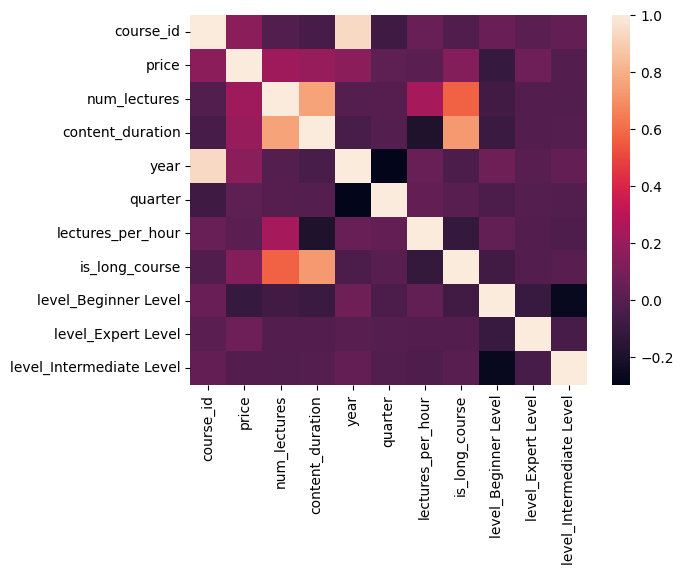

In [147]:
numberic_df = df.select_dtypes(include=['number'])
sns.heatmap(numberic_df.corr(),annot=False )

In [148]:
df.columns

Index(['published', 'course_id', 'course_title', 'url', 'price',
       'num_lectures', 'content_duration', 'subject', 'published.1', 'year',
       'quarter', 'month', 'content_duration_cat', 'price_cat',
       'lectures_per_hour', 'is_long_course', 'level_Beginner Level',
       'level_Expert Level', 'level_Intermediate Level',
       'subject_Graphic Design', 'subject_Musical Instruments',
       'subject_Web Development'],
      dtype='object')

In [149]:
X = df[['num_lectures' , 'content_duration' , 'year' , 'quarter' ,
         'is_long_course' ,'lectures_per_hour','level_Beginner Level' , 'level_Expert Level' , 'level_Intermediate Level',
         'subject_Graphic Design' , 'subject_Musical Instruments',
         'subject_Web Development']]
X

,num_lectures,content_duration,year,quarter,is_long_course,lectures_per_hour,level_Beginner Level,level_Expert Level,level_Intermediate Level,subject_Graphic Design,subject_Musical Instruments,subject_Web Development
0,51,1.5,2017,1,0,31.875000,0.0,0.0,0.0,False,False,False
1,51,2.5,2016,4,0,19.615385,0.0,0.0,1.0,False,False,False
2,36,3.0,2017,2,0,11.612903,0.0,0.0,0.0,False,False,False
3,26,2.0,2016,4,0,12.380952,0.0,0.0,1.0,False,False,False
4,38,2.5,2015,2,0,14.615385,0.0,1.0,0.0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2777,140,15.5,2016,4,1,8.974359,0.0,0.0,0.0,False,False,True
2778,21,2.0,2016,2,0,10.000000,0.0,0.0,0.0,False,False,True
2779,42,3.5,2017,1,0,11.666667,1.0,0.0,0.0,False,False,True
2780,38,3.0,2016,3,0,12.258065,0.0,0.0,0.0,False,False,True


In [150]:
y = df['price']
y

0       200
1        45
2        95
3       200
4       195
       ... 
2777    150
2778    100
2779     25
2780     50
2781     45
Name: price, Length: 2782, dtype: int64

- **Scaling**

In [151]:
from sklearn.preprocessing import MinMaxScaler
xmm = MinMaxScaler() # for the input features
ymm = MinMaxScaler() # for the target features

In [152]:
X_scaled = xmm.fit_transform(X)
y_scaled = ymm.fit_transform(y.values.reshape(-1,1))

In [153]:
X_scaled

array([[0.10262009, 0.01960784, 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.10262009, 0.03392014, 0.8       , ..., 0.        , 0.        ,
        0.        ],
       [0.069869  , 0.04107628, 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.08296943, 0.04823243, 1.        , ..., 0.        , 0.        ,
        1.        ],
       [0.07423581, 0.04107628, 0.8       , ..., 0.        , 0.        ,
        1.        ],
       [0.0349345 , 0.02676399, 0.4       , ..., 0.        , 0.        ,
        1.        ]], shape=(2782, 12))

In [154]:
y_scaled

array([[1.   ],
       [0.225],
       [0.475],
       ...,
       [0.125],
       [0.25 ],
       [0.225]], shape=(2782, 1))

---
### Splitting Dataset 

In [155]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X_scaled,y_scaled , test_size=0.2 , random_state=42)

print(f'X train shape: {X_train.shape}')
print(f'y train shape: {y_train.shape}')
print(f'X test shape: {X_test.shape}')
print(f'y test shape: {y_test.shape}')


X train shape: (2225, 12)
y train shape: (2225, 1)
X test shape: (557, 12)
y test shape: (557, 1)


---
### Building Models

In [156]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor , ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor


In [157]:
lr = LinearRegression()
svr = SVR()
rfr = RandomForestRegressor()
gbr = GradientBoostingRegressor()
etr = ExtraTreesRegressor()
dtr = DecisionTreeRegressor()
knn = KNeighborsRegressor()
xgbr = XGBRegressor()

---
### Parameters Lists

In [158]:
# Linear Regression
param1 = {}
param1['regressor'] = [lr]

# Ridge Regression
param_ridge = {}
param_ridge['regressor'] = [Ridge()]
param_ridge['regressor__alpha'] = [0.1, 1.0, 10.0, 100.0]

# SVR
param2 = {}
param2['regressor'] = [svr]
param2['regressor__C'] = [1, 10, 100]
param2['regressor__kernel'] = ['rbf']
param2['regressor__gamma'] = ['scale', 0.1, 0.01]
param2['regressor__epsilon'] = [0.1, 0.2, 0.5]

# Random Forest
param3 = {}
param3['regressor'] = [rfr]
param3['regressor__n_estimators'] = [200, 500]
param3['regressor__max_depth'] = [5, 8, 12]
param3['regressor__min_samples_leaf'] = [5, 10, 20]
param3['regressor__max_features'] = ['sqrt']

# Gradient Boosting
param4 = {}
param4['regressor'] = [gbr]
param4['regressor__n_estimators'] = [300, 500]
param4['regressor__learning_rate'] = [0.01, 0.05, 0.1]
param4['regressor__max_depth'] = [3, 4, 5]
param4['regressor__subsample'] = [0.8, 0.9]

# XGBoost
param5 = {}
param5['regressor'] = [xgbr]
param5['regressor__n_estimators'] = [500, 1000] 
param5['regressor__learning_rate'] = [0.01, 0.05]
param5['regressor__max_depth'] = [3, 5, 7]
param5['regressor__subsample'] = [0.8, 0.9]
param5['regressor__colsample_bytree'] = [0.8, 0.9]
param5['regressor__reg_lambda'] = [1, 10]

# KNN
param6 = {}
param6['regressor'] = [knn]
param6['regressor__n_neighbors'] = [5, 9, 15, 21]
param6['regressor__weights'] = ['distance']
param6['regressor__metric'] = ['manhattan']


In [159]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([('regressor' , lr)])
params = [param1, param2 , param3,param4,
          param5, param6]

In [160]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(pipeline, params , cv=5 , scoring='neg_mean_squared_error', verbose=2 , n_jobs=-1)

In [161]:
gs.fit(X_train , y_train)

Fitting 5 folds for each of 182 candidates, totalling 910 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'regressor': [LinearRegression()]}, {'regressor': [SVR()], 'regressor__C': [1, 10, ...], 'regressor__epsilon': [0.1, 0.2, ...], 'regressor__gamma': ['scale', 0.1, ...], ...}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the hig

In [162]:
gs.best_params_

{'regressor': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...),
 'regressor__colsample_bytree': 0.9,
 'regressor__learning_rate': 0.01,
 'regressor__max_depth': 3,
 'regressor__n_estimators': 500,
 'regressor__reg_lambda': 10,
 'regressor__subsample': 0.8}

In [ ]:
-gs.best_score_

np.float64(0.06873376930542822)

---
## Model Testing & Evaluation

In [164]:
y_pred = gs.predict(X_test)
y_pred


array([0.37048146, 0.34355006, 0.30234376, 0.3799694 , 0.26427782,
       0.35296586, 0.2056497 , 0.35323477, 0.28312   , 0.22607924,
       0.24264745, 0.16585828, 0.19695503, 0.11599777, 0.18529572,
       0.20241794, 0.14230385, 0.26722062, 0.20180297, 0.28562847,
       0.34720576, 0.4465411 , 0.38823804, 0.32824472, 0.2829141 ,
       0.33210787, 0.35100013, 0.38170287, 0.24214996, 0.18482004,
       0.13868321, 0.3262657 , 0.24501468, 0.2848377 , 0.344557  ,
       0.12229169, 0.3373998 , 0.16670884, 0.39771146, 0.4089497 ,
       0.30062556, 0.36448354, 0.21195914, 0.17332014, 0.1711755 ,
       0.24187988, 0.451131  , 0.41613093, 0.32201502, 0.14594084,
       0.12517676, 0.14261268, 0.32169148, 0.45572564, 0.30004257,
       0.3075697 , 0.18694869, 0.38417658, 0.15996574, 0.4651136 ,
       0.16626506, 0.2344022 , 0.21065778, 0.1339814 , 0.20922752,
       0.20905633, 0.23254542, 0.2863131 , 0.29028815, 0.38915533,
       0.3622695 , 0.44121218, 0.19452065, 0.37178904, 0.38893

In [175]:
y_pred_actual = ymm.inverse_transform(y_pred.reshape(-1,1))
y_test_actual = ymm.inverse_transform(y_test.reshape(-1,1))

from sklearn.metrics import mean_absolute_error , root_mean_squared_error 

print(f'MAE : {mean_absolute_error(y_true=y_test_actual , y_pred=y_pred_actual)}')
print(f'RMSE : {root_mean_squared_error(y_true=y_test_actual , y_pred=y_pred_actual)}')




MAE : 37.807412745066564
RMSE : 50.971195416971405


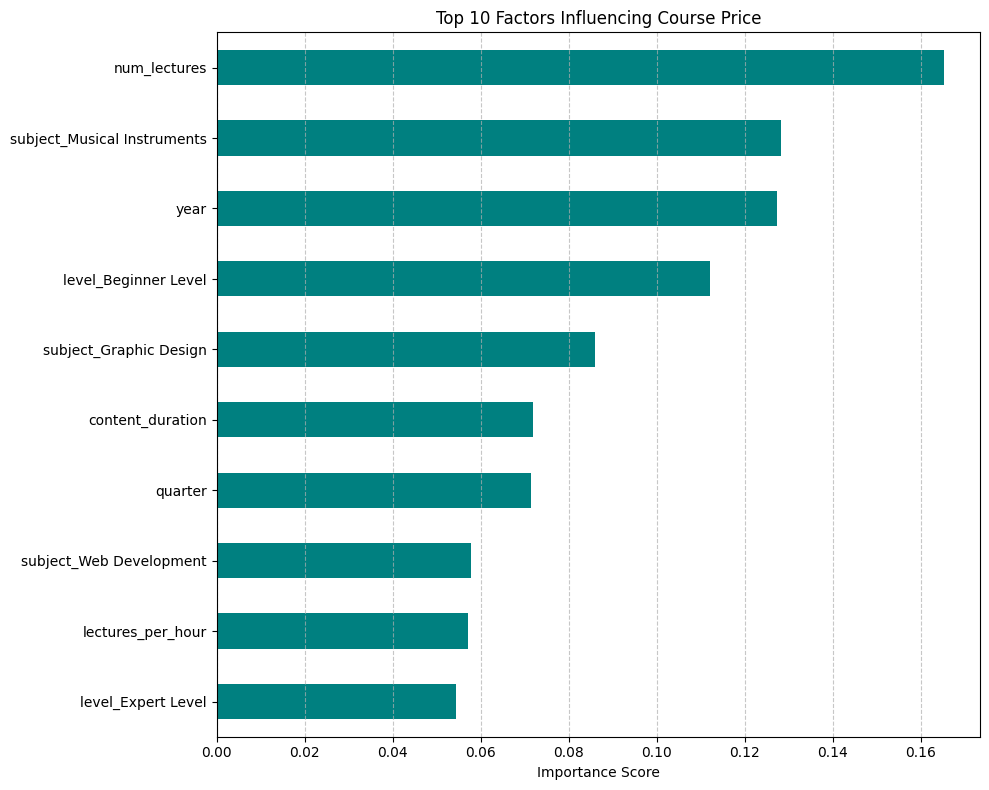

In [176]:


best_model = gs.best_estimator_.named_steps['regressor']


try:
    feature_names = X.columns 
except:
    feature_names = gs.best_estimator_.feature_names_in_

importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Factors Influencing Course Price')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
### Saving Best Model

In [177]:
import joblib
joblib.dump(gs.best_estimator_,'best_regression_model.pkl')

['best_regression_model.pkl']